In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.model_selection import train_test_split 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.naive_bayes import GaussianNB,CategoricalNB,BernoulliNB
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler

In [2]:
# Import Data

loan = pd.read_csv("C:\\Users\\coola\\OneDrive\\Desktop\\Machine Learning Case Study\\train.csv")

In [3]:
# Checking Data info

loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
# Missing Values

loan.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
# Missing value in %

loan.isna().sum() / loan.shape[0] * 100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [6]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
# Store loan_id and drop form dataset 

loan_id = loan['Loan_ID']

In [8]:
# Drop loan id

loan.drop(columns = 'Loan_ID', inplace = True)

In [9]:
loan['Dependents'] = loan['Dependents'].replace('3+', 3)
loan['Dependents'] = pd.to_numeric(
    loan['Dependents'],
    errors='coerce'
)

In [10]:
loan_cat = loan.select_dtypes('object')
loan_int = loan.select_dtypes(['int64', 'float64'])

In [11]:
loan_int.corr()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
Dependents,1.000000,0.118679,0.027259,0.163997,-0.100484,-0.050082
ApplicantIncome,0.118679,1.000000,-0.116605,0.570909,-0.045306,-0.014715
CoapplicantIncome,0.027259,-0.116605,1.000000,0.188619,-0.059878,-0.002056
LoanAmount,0.163997,0.570909,0.188619,1.000000,0.039447,-0.008433
Loan_Amount_Term,-0.100484,-0.045306,-0.059878,0.039447,1.000000,0.001470
Credit_History,-0.050082,-0.014715,-0.002056,-0.008433,0.001470,1.000000


<Axes: >

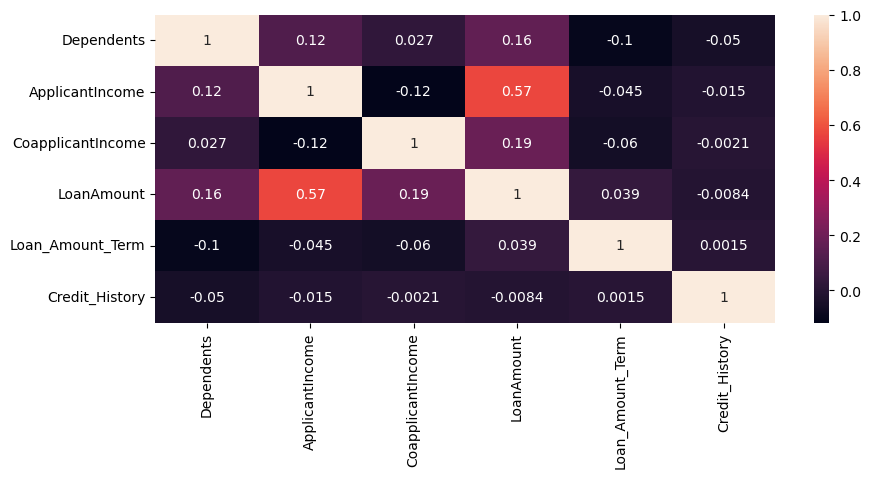

In [12]:

plt.figure(figsize=(10,4))
sns.heatmap(loan_int.corr(),annot=True)

In [13]:
def contionous_var(x):
    # checking missing value
    x_total=x.shape[0]
    x_missing=x.isna().sum()
    x_per=x_missing/x_total * 100

    # checking outlier 

    q1=x.quantile(0.25)
    q3=x.quantile(0.75)
    iqr=q3-q1
    low_iqr= q1 - 1.5 * iqr
    upp_iqr= q3 + 1.5 * iqr

    return pd.Series([x.dtype,x.count(),x_total,x_missing,x_per,x.std(),x.var(),x.mean(),x.quantile(0.99),
                      x.max(),upp_iqr,x.quantile(0.01),x.min(),low_iqr,
                     x.quantile(0.05),x.quantile(0.10),x.quantile(0.25),x.quantile(0.50),
                      x.quantile(0.75),x.quantile(0.90),x.quantile(0.95),x.quantile(0.99)],
                    
                    index=['dtype','n','x_total','x_missing','x_per','std','var','mean','q99','max','upp_outlier','q1','min',
                          'low_outlier','q5','q10','q25','q50','q75','p90','p95','p99']
                    
                    )

In [14]:
loan_int.apply(contionous_var)

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
dtype,float64,int64,float64,float64,float64,float64
n,599,614,614,592,600,564
x_total,614,614,614,614,614,614
x_missing,15,0,0,22,14,50
x_per,2.442997,0.0,0.0,3.583062,2.28013,8.143322
std,1.015216,6109.041673,2926.248369,85.587325,65.12041,0.364878
var,1.030664,37320390.167181,8562929.518387,7325.190241,4240.66778,0.133136
mean,0.762938,5403.459283,1621.245798,146.412162,342.0,0.842199
q99,3.0,32540.41,8895.89,496.36,480.0,1.0
max,3.0,81000,41667.0,700.0,480.0,1.0


In [15]:
knn_imputer = KNNImputer(n_neighbors=5,weights='uniform')

In [16]:
loan_int = pd.DataFrame(knn_imputer.fit_transform(loan_int),columns=['Dependents','ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History'])
loan_int.isna().sum()

Dependents           0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
dtype: int64

In [17]:
loan_cat.describe()

,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
count,601,611,614,582,614,614
unique,2,2,2,2,3,2
top,Male,Yes,Graduate,No,Semiurban,Y
freq,489,398,480,500,233,422


In [18]:
simple = SimpleImputer(strategy='most_frequent')
loan_cat = pd.DataFrame(simple.fit_transform(loan_cat),columns=['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status'])

In [19]:
loan_cat['Loan_Status'] = np.where(loan_cat.Loan_Status == 'Y' , 1, 0)

In [20]:
y = loan_cat['Loan_Status']

In [21]:
loan_cat.drop(columns = 'Loan_Status' , inplace = True)

In [22]:
loan_cat = pd.get_dummies(loan_cat,drop_first  = True)

In [23]:
loan_cat.replace({'Education_Not Graduate':'Education_Not_Graduate'},inplace=True)

In [24]:
loan_final = pd.concat([loan_int, loan_cat] ,axis = 1)

In [25]:
loan_final.rename({'Education_Not Graduate':'Education_Not_Graduate'},inplace=True)

In [26]:
bool_cols = loan_final.select_dtypes(include='bool').columns

loan_final[bool_cols] = loan_final[bool_cols].astype(int)

In [29]:
vif = pd.DataFrame()
vif["Feature"]=loan_final.columns
vif["vif_factor"] = [variance_inflation_factor(loan_final,i) for i in range(len(loan_final.columns))]
vif

,Feature,vif_factor
0,Dependents,1.851228
1,ApplicantIncome,2.966918
2,CoapplicantIncome,1.478522
3,LoanAmount,6.837608
4,Loan_Amount_Term,10.812842
5,Credit_History,5.977495
6,Gender_Male,6.078035
7,Married_Yes,3.700060
8,Education_Not Graduate,1.310172
9,Self_Employed_Yes,1.176360


In [30]:
feature = list(vif.loc[vif.vif_factor < 3,"Feature"] )
x = loan_final[feature]
y

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=10)

In [33]:
x_train.shape

(429, 7)

In [35]:
x_test.shape

(185, 7)

In [36]:
y_train.shape

(429,)

In [37]:
y_test.shape

(185,)

In [38]:
gnb_class = GaussianNB()

In [39]:
gnb_class.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [40]:
pred_y=gnb_class.predict(x_train)
accuracy_score(y_train,pred_y)

0.662004662004662

In [41]:
pred_y_=gnb_class.predict(x_test)
accuracy_score(y_test,pred_y_)

0.7027027027027027

In [42]:
print(classification_report(y_train,gnb_class.predict(x_train)))

              precision    recall  f1-score   support

           0       0.41      0.08      0.13       140
           1       0.68      0.94      0.79       289

    accuracy                           0.66       429
   macro avg       0.54      0.51      0.46       429
weighted avg       0.59      0.66      0.58       429



In [43]:
print(classification_report(y_test,gnb_class.predict(x_test)))

              precision    recall  f1-score   support

           0       0.29      0.04      0.07        52
           1       0.72      0.96      0.82       133

    accuracy                           0.70       185
   macro avg       0.50      0.50      0.45       185
weighted avg       0.60      0.70      0.61       185

